In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
# imagefolder
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from tqdm import tqdm

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
train_dataset = ImageFolder(root=r'data\raw', transform=transform)


In [5]:
# examine the dataset
print(f"Number of classes: {len(train_dataset.classes)}")

# shape of the first image
print(f"Shape of the first image: {train_dataset[0][0].shape}")

# class names
print(f"Class names: {train_dataset.classes}")

Number of classes: 2
Shape of the first image: torch.Size([3, 224, 224])
Class names: ['image', 'text']


In [8]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

In [ ]:
# pytorch model, binary classification, 2 classes, screenshots of images and screenshots of text

class ImgTxtClassifier(torch.nn.Module):
    def __init__(self):
        super(ImgTxtClassifier, self).__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1)
        self.pool = torch.nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1)
        self.fc1 = torch.nn.Linear(32 * 56 * 56, 128)
        self.fc2 = torch.nn.Linear(128, 1)  # binary classification

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(-1, 32 * 56 * 56)  # flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = ImgTxtClassifier()
criterion = torch.nn.BCEWithLogitsLoss()  # for binary classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses = []
test_losses = []

In [16]:

epochs = 10
for epoch in tqdm(range(epochs), desc="Training Progress (epochs)"):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(train_loader):
        optimizer.zero_grad()
        labels = labels.float().unsqueeze(1)  # convert to float and add dimension for BCEWithLogitsLoss
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        # scheduler.step()
        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))
    # get last learning rate from scheduler
    # print(scheduler.get_last_lr())
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            labels = labels.float().unsqueeze(1)  # convert to float and add dimension for BCEWithLogitsLoss
            loss = criterion(outputs, labels)
            test_loss += loss.item()

    test_losses.append(test_loss / len(test_loader))

    print(
        f"Epoch {epoch+1:2d} | "
        # f"LR={scheduler.get_last_lr()[0]:.6f} | "
        f"Train={train_losses[-1]:.4f} | "
        f"Val={test_losses[-1]:.4f}"
    )

Training Progress (epochs):  10%|█         | 1/10 [00:21<03:10, 21.12s/it]

Epoch  1 | Train=0.0676 | Val=0.0420


Training Progress (epochs):  20%|██        | 2/10 [00:44<02:57, 22.16s/it]

Epoch  2 | Train=0.0349 | Val=0.0554


Training Progress (epochs):  30%|███       | 3/10 [01:06<02:36, 22.29s/it]

...

Epoch  8 | Train=0.0075 | Val=0.0043


Training Progress (epochs):  90%|█████████ | 9/10 [03:23<00:22, 22.91s/it]

Epoch  9 | Train=0.0046 | Val=0.0026


Training Progress (epochs): 100%|██████████| 10/10 [03:46<00:00, 22.66s/it]

Epoch 10 | Train=0.0025 | Val=0.0020


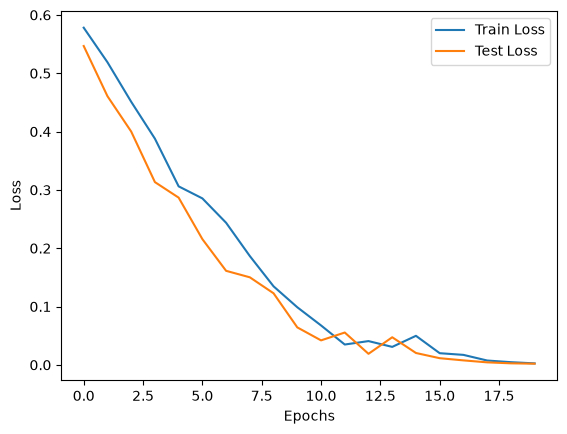

In [18]:
import matplotlib.pyplot as plt
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [19]:
# accuracy
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = torch.round(torch.sigmoid(outputs))  # convert logits to probabilities and round
        total += labels.size(0)
        correct += (predicted.squeeze() == labels).sum().item()

accuracy = correct / total
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [ ]:
from image_classifier.scaffolding import DataLoaderTrainer, EarlyStopping, LossHistory, Preliminary_information, ProgressPrinter

In [ ]:
history = LossHistory()

trainer = DataLoaderTrainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    callbacks=[history, EarlyStopping(patience=10), ProgressPrinter()]
)

In [ ]:
ctx = trainer.fit(train_loader, val_loader=val_loader, epochs=100)

ValueError: Target size (torch.Size([32])) must be the same as input size (torch.Size([32, 2]))